In [15]:
import os

print(os.listdir("/content/drive/MyDrive/Fake-News-RAG/datasets"))

['test_clean.csv', 'train_clean.csv', 'valid_clean.csv']


In [16]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

train_df = pd.read_csv(
    "/content/drive/MyDrive/Fake-News-RAG/datasets/train_clean.csv"
)

valid_df = pd.read_csv(
    "/content/drive/MyDrive/Fake-News-RAG/datasets/valid_clean.csv"
)

test_df = pd.read_csv(
    "/content/drive/MyDrive/Fake-News-RAG/datasets/test_clean.csv"
)

print(train_df.head())
print(train_df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                                                text  label
0  Says the Annies List political group supports ...      1
1  When did the decline of coal start? It started...      0
2  Hillary Clinton agrees with John McCain "by vo...      0
3  Health care reform legislation is likely to ma...      1
4  The economic turnaround started at the end of ...      0
(10240, 2)


In [17]:
# Check dataset size
print(train_df.shape)

# Preview the data
print(train_df.head())

# Check class distribution
print(train_df["label"].value_counts())

(10240, 2)
                                                text  label
0  Says the Annies List political group supports ...      1
1  When did the decline of coal start? It started...      0
2  Hillary Clinton agrees with John McCain "by vo...      0
3  Health care reform legislation is likely to ma...      1
4  The economic turnaround started at the end of ...      0
label
0    5752
1    4488
Name: count, dtype: int64


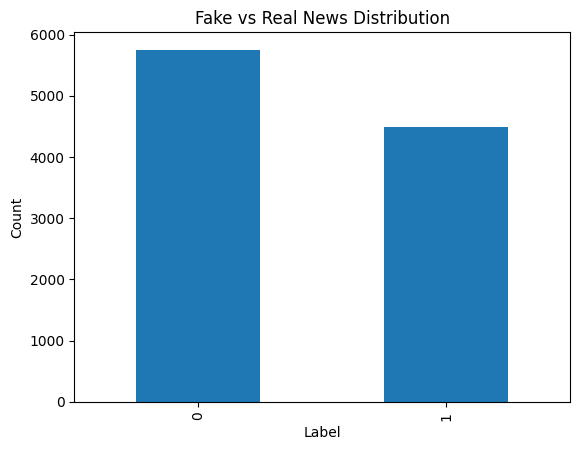

In [18]:
import matplotlib.pyplot as plt

train_df["label"].value_counts().plot(kind="bar")

plt.title("Fake vs Real News Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [19]:
print(train_df["label"].value_counts())

label
0    5752
1    4488
Name: count, dtype: int64


In [21]:
train_df["text_length"] = train_df["text"].apply(len)

train_df["text_length"].describe()

,text_length
count,10240.000000
mean,106.918750
std,59.917722
min,11.000000
25%,73.000000
50%,99.000000
75%,132.250000
max,3192.000000


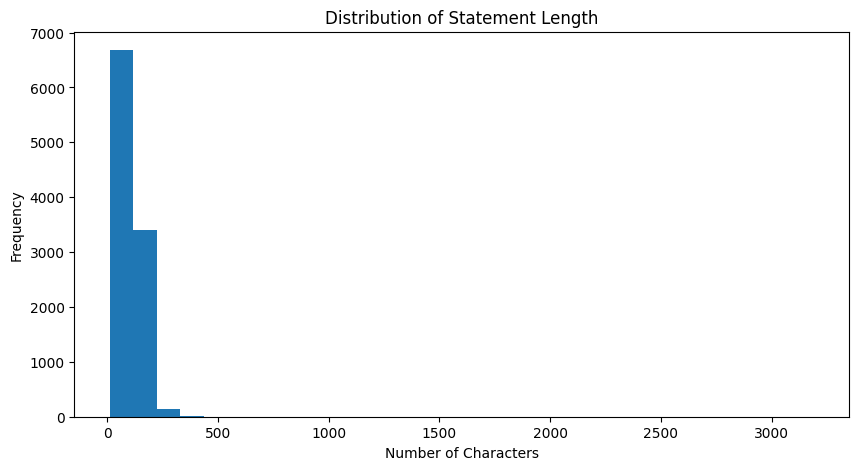

In [22]:
plt.figure(figsize=(10, 5))

plt.hist(train_df["text_length"], bins=30)

plt.title("Distribution of Statement Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

In [23]:
train_df.sort_values(
    by="text_length",
    ascending=False
).head(10)

,text,label,text_length
1280,"Hospitals, doctors, MRIs, surgeries and so for...",0,3192
7550,The vast majority of the money I got was from ...,1,2099
6119,Georgia has the most restrictive ballot access...,0,1592
2142,The fact is that although we have had a presid...,1,538
9962,Barbara Buono by the numbers: As a Trenton pol...,0,395
7271,"Portland Public Schools invites well-paid, wel...",1,391
4193,Let's pay attention to kids who are not going ...,0,370
427,Right now one of our highest job growth sector...,0,370
4034,Mike Madigan made a fortune on tax appeals Sav...,1,343
5026,He (Obama) has done several things well. Most ...,1,342


In [24]:
train_df.sort_values(
    by="text_length"
).head(10)

,text,label,text_length
6759,On torture.,0,11
709,On abortion,1,11
1071,On torture.,0,11
1014,On abortion,0,11
6527,On abortion.,1,12
7358,On gun policy,0,13
6131,Were bankrupt.,1,14
8642,On oil drilling,0,15
7820,On gay marriage,1,15
8283,On Common Core.,1,15


In [25]:
label_percent = train_df["label"].value_counts(normalize=True) * 100

print(label_percent)

label
0    56.171875
1    43.828125
Name: proportion, dtype: float64


In [26]:
print("Average text length:", train_df["text_length"].mean())

Average text length: 106.91875


In [27]:
print("Minimum length:", train_df["text_length"].min())
print("Maximum length:", train_df["text_length"].max())

Minimum length: 11
Maximum length: 3192


In [28]:
train_df.to_csv(
    "/content/drive/MyDrive/Fake-News-RAG/datasets/train_with_length.csv",
    index=False
)